In [8]:
import os
from copy import deepcopy
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.lorenz import LorenzIntraTrajectoryGLSConfig, run_lorenz_intra_trajectory_gls_experiment
from mfsindy.experiments import (
    build_polynomial_intra_trajectory_artifacts,
    build_polynomial_rollout_models,
    evaluate_windowed_rollout_models,
    fit_intra_trajectory_gls_model_objects,
    format_model_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_single_trajectory,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = LorenzIntraTrajectoryGLSConfig(
    n_runs=25,
    t0=0.0,
    t1=10.0,
    dt=1e-3,
    noise_level=0.1,
    seed_base=0,
    results_dir="results",
    results_filename="lorenz_weighted_errors.csv",
)


# Lorenz Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

The classical Lorenz--63 system is given by

$$
\begin{aligned}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x(\rho - z) - y, \\
\dot{z} &= xy - \beta z.
\end{aligned}
$$

We use the standard parameter values $(\sigma, \rho, \beta) = (10, 28, 8/3)$.

Let $U=(x,y,z)^\top$ denote the system state. We model additive perturbation error by adding a zero-mean random noise term $\epsilon$ to $U$, that is,
$$
U^{\mathrm{noisy}} = U + \epsilon.
$$
Where
$$
\mathbb{E}[\epsilon] = 0,
\qquad
\mathrm{Var}(\epsilon) \propto \alpha^2 \|U\|^2.
$$

## Trajectories

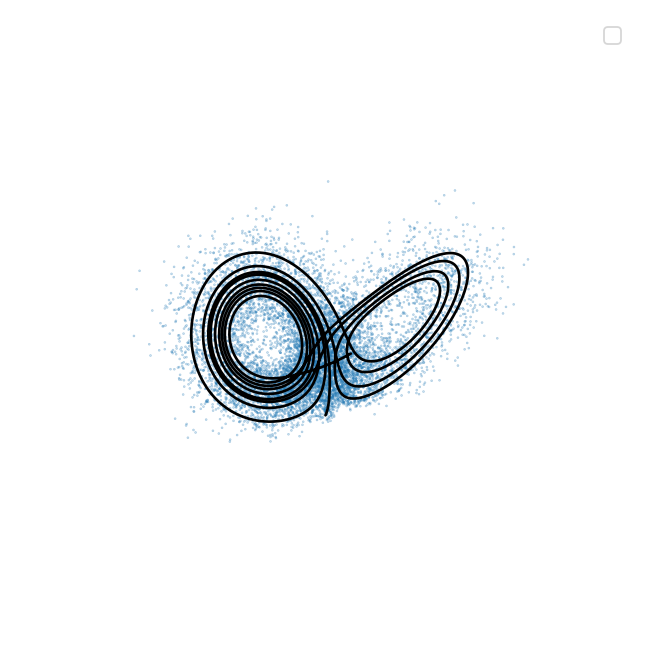

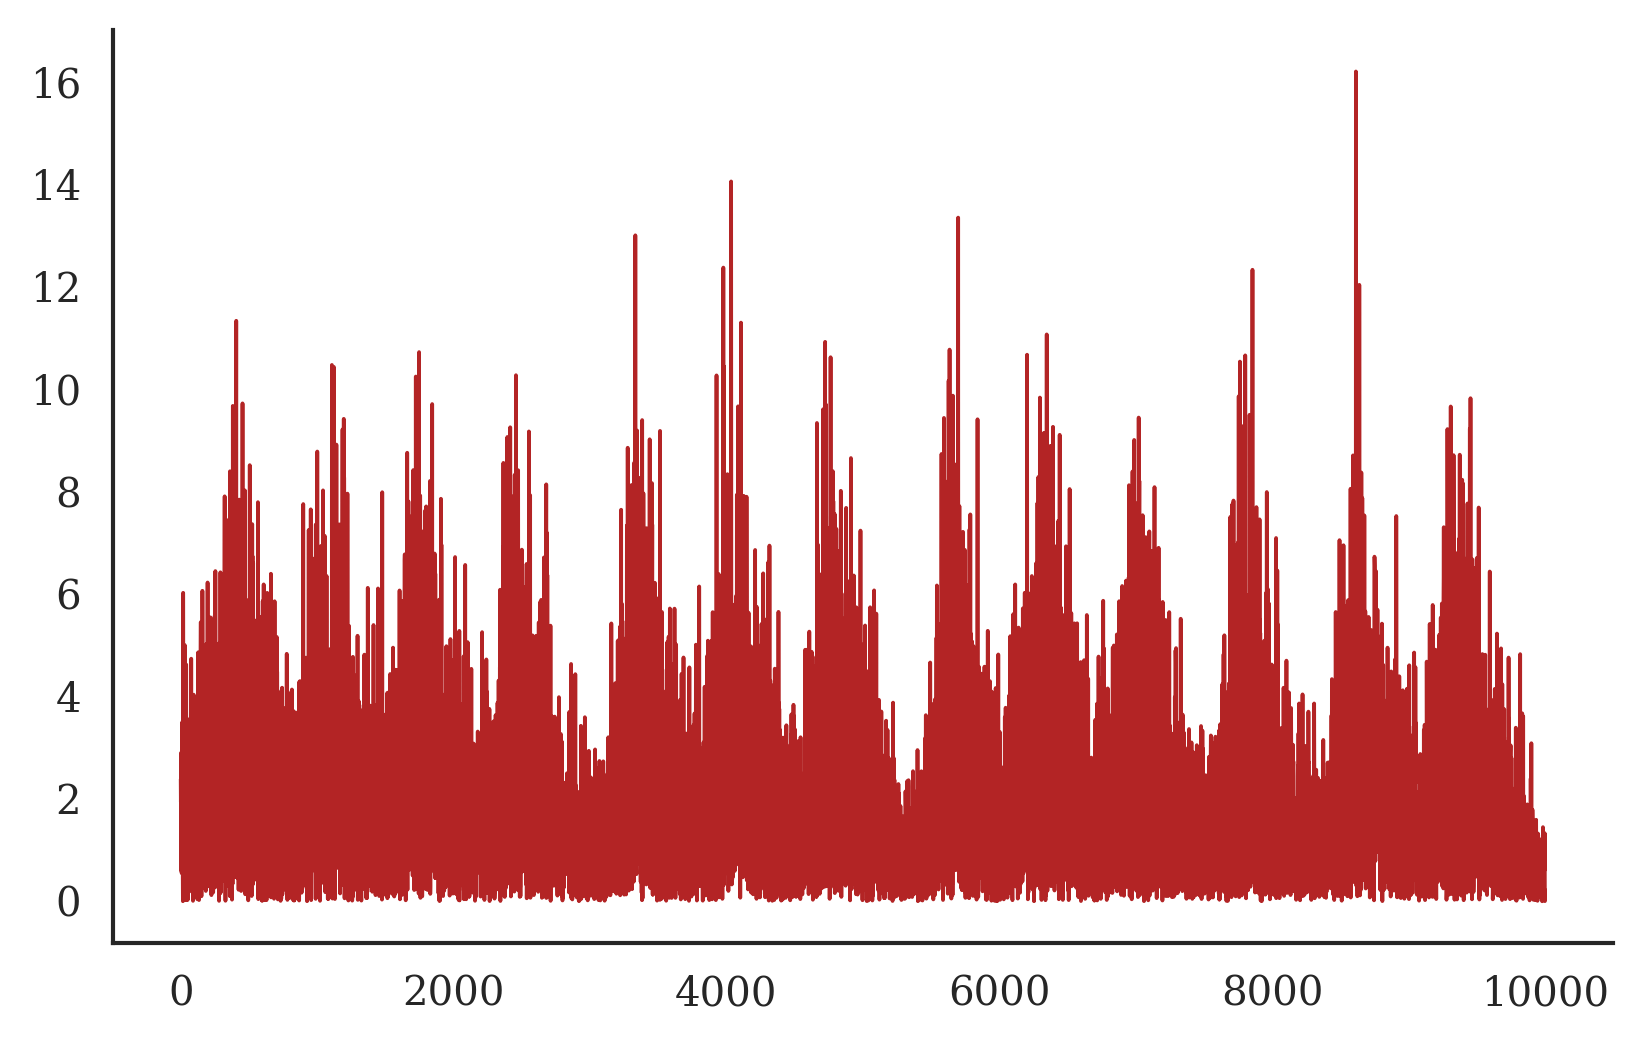

In [9]:
from mfsindy.cases.lorenz import generate_lorenz_trajectory
from mfsindy.cases.lorenz_plots import plot_trajectories_additive_noise, plot_residuals

y0 = np.array([10.0,-10.0,30.0])
_, X_true, _ = generate_lorenz_trajectory(
    y0=y0,
    noise_level=0.0,
    seed=0,
    T=10
)
X_noisy = plot_trajectories_additive_noise(x_true=X_true,alpha=0.1)
plot_residuals(x_true=X_true, x_noisy=X_noisy)


## Hyperparameter Selection

Use one noisy Lorenz trajectory realisation, split it 80-20 in time, and tune the weak-form hyperparameters separately for each model. Because Lorenz is chaotic, the score is not based on one long validation rollout: instead, each candidate is evaluated on many short validation windows, and the mean short-horizon rollout $R^2$ is maximized. After tuning, refit each model on the full trajectory and print the resulting equations.


In [10]:
# SEARCH_GRID = {
#     "stlsq_threshold": [0.05, 0.1, 0.2],
#     "poly_degree": [2],
#     "H_xt": [0.005, 0.01, 0.025],
# }

# SHORT_HORIZON = 0.1
# WINDOW_STRIDE = 0.05

# search_y0 = np.array([10.0, -10.0, 30.0])
# t_search, X_clean_search, _ = generate_lorenz_trajectory(
#     y0=search_y0,
#     T=cfg.t1 - cfg.t0,
#     dt=cfg.dt,
#     noise_level=0.0,
#     seed=cfg.seed_base,
# )
# variance_search = np.maximum((cfg.noise_level * np.linalg.norm(X_clean_search, axis=1)) ** 2, 1e-8)
# rng_search = np.random.default_rng(cfg.seed_base + 123)
# X_noisy_search = X_clean_search + np.sqrt(variance_search)[:, None] * rng_search.standard_normal(size=X_clean_search.shape)

# X_train, X_val, t_train, t_val = split_single_trajectory(
#     X_noisy_search,
#     t_search,
#     validation_fraction=0.2,
# )
# variance_train = variance_search[: X_train.shape[0]]
# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# state_names = ("x", "y", "z")
# window_size = min(X_val.shape[0], max(2, int(round(SHORT_HORIZON / cfg.dt)) + 1))
# stride = max(1, int(round(WINDOW_STRIDE / cfg.dt)))

# def evaluate_candidate(candidate_cfg):
#     artifacts = build_polynomial_intra_trajectory_artifacts(
#         X_train,
#         t_train,
#         variance=variance_train,
#         poly_degree=candidate_cfg.poly_degree,
#         derivative_order=candidate_cfg.derivative_order,
#         include_bias=candidate_cfg.include_bias,
#         K=candidate_cfg.K,
#         H_xt=candidate_cfg.H_xt,
#         p=candidate_cfg.p,
#         weak_seed=candidate_cfg.seed_base + 40_000,
#     )
#     fitted_models = fit_intra_trajectory_gls_model_objects(candidate_cfg, artifacts, methods)
#     rollout_models = build_polynomial_rollout_models(
#         {name: np.asarray(model.optimizer.coef_) for name, model in fitted_models.items()},
#         poly_degree=candidate_cfg.poly_degree,
#         reference_trajectory=X_train,
#         state_names=state_names,
#         include_bias=candidate_cfg.include_bias,
#     )
#     return evaluate_windowed_rollout_models(
#         rollout_models,
#         X_val,
#         t_grid=t_val,
#         window_size=window_size,
#         stride=stride,
#         metric_name="short_rollout_r2",
#     )

# search_results = {}
# best_params_by_model = {}
# tuned_cfg_by_model = {}
# tuned_models = {}

# for target_model in methods:
#     search = optimize_hyperparams(
#         cfg,
#         param_grid=SEARCH_GRID,
#         evaluate=evaluate_candidate,
#         score_fn=make_metric_scorer(source=target_model, metric="short_rollout_r2"),
#         maximize=True,
#     )
#     tuned_cfg = deepcopy(search.best_config)
#     search_results[target_model] = search
#     best_params_by_model[target_model] = search.best_params
#     tuned_cfg_by_model[target_model] = tuned_cfg
#     full_artifacts = build_polynomial_intra_trajectory_artifacts(
#         X_noisy_search,
#         t_search,
#         variance=variance_search,
#         poly_degree=tuned_cfg.poly_degree,
#         derivative_order=tuned_cfg.derivative_order,
#         include_bias=tuned_cfg.include_bias,
#         K=tuned_cfg.K,
#         H_xt=tuned_cfg.H_xt,
#         p=tuned_cfg.p,
#         weak_seed=tuned_cfg.seed_base + 40_001,
#     )
#     full_fitted_models = fit_intra_trajectory_gls_model_objects(tuned_cfg, full_artifacts, methods)
#     tuned_models[target_model] = build_polynomial_rollout_models(
#         {name: np.asarray(model.optimizer.coef_) for name, model in full_fitted_models.items()},
#         poly_degree=tuned_cfg.poly_degree,
#         reference_trajectory=X_noisy_search,
#         state_names=state_names,
#         include_bias=tuned_cfg.include_bias,
#     )[target_model]

# print(pd.DataFrame(best_params_by_model).T)
# print(format_model_equations(tuned_models, precision=3))


## Run

In [11]:
# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# df_errors_parts = []
# for method_name in methods:
#     method_cfg = deepcopy(tuned_cfg_by_model[method_name])
#     method_cfg.results_filename = f"lorenz_part2_{method_name.lower().replace(' ', '_')}.csv"
#     df_method, _, _ = run_lorenz_intra_trajectory_gls_experiment(method_cfg)
#     df_errors_parts.append(df_method[df_method["method"] == method_name].copy())

# df_errors = pd.concat(df_errors_parts, ignore_index=True)
# errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
# df_errors.to_csv(errors_path, index=False)



## Errors

In [12]:
methods = ["No weighting", "Variance GLS", "Ones GLS"]


errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nMedian L1 errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L1_errors[m]):.3e}")

print("\nMedian L0 support errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L0_errors[m]):.3e}")



Median L1 errors (reloaded from CSV):
No weighting   : 1.161e-01
Variance GLS   : 5.726e-02
Ones GLS       : 6.759e-02

Median L0 support errors (reloaded from CSV):
No weighting   : 5.714e-01
Variance GLS   : 2.857e-01
Ones GLS       : 2.857e-01


### L1 Error

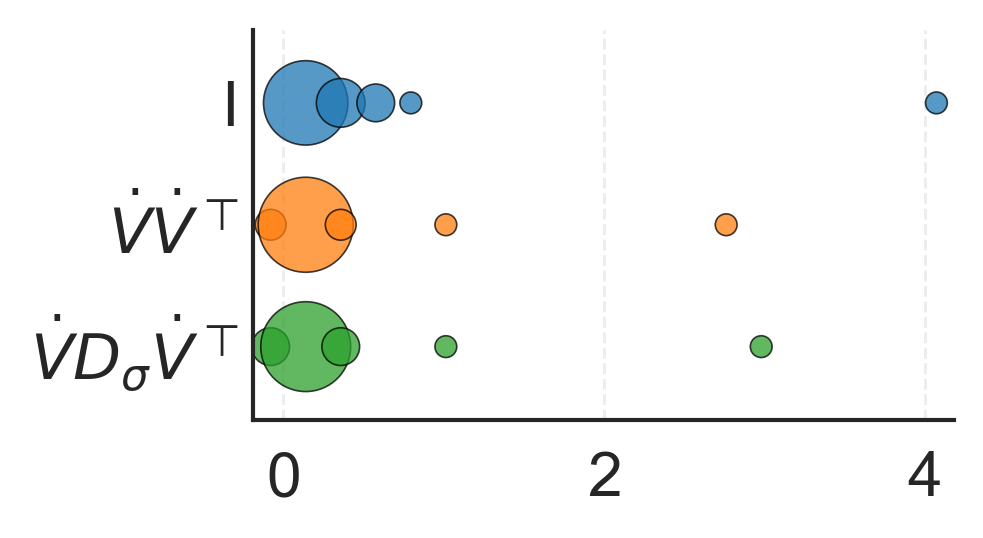

In [13]:
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}D_\sigma\dot{V}^\top$",r"$\dot{V}\dot{V}^\top$","I"]

all_l1_values = np.concatenate([
    np.asarray(L1_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l1_values))-0.001
xmax = float(np.max(all_l1_values))+0.001
pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)

l1_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L1_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l1_xlim,
    save_path="results/l1_2",
)


### L0 Error

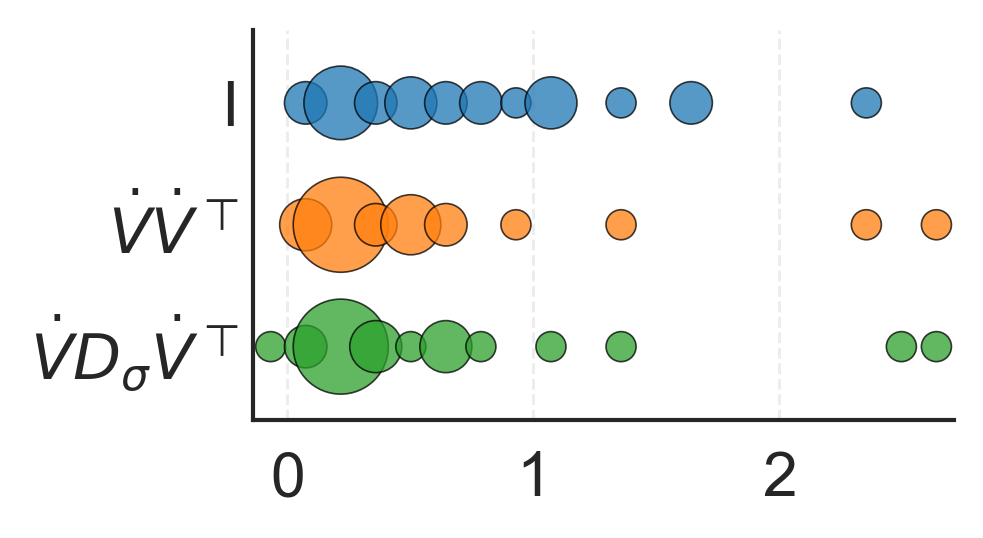

In [14]:
all_l0_values = np.concatenate([
    np.asarray(L0_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l0_values))-0.01
xmax = float(np.max(all_l0_values))+0.01

pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
l0_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L0_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l0_xlim,
    save_path="results/l0_2"
)
